In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

files = os.listdir('/content/drive/MyDrive')

print("Files in MyDrive:")
for file in files:
    print(file)

Files in MyDrive:
Colab Notebooks
Untitled document (1).gdoc
Untitled presentation.gslides
Untitled spreadsheet.gsheet
DriveFlix
Sharer.pw
Classroom
CoinbaseWalletBackups
Untitled folder
Untitled folderghgg
inbound6353087746125554309.docx
Assignment .gdoc
Untitled document.gdoc
Essay for ICCR.gdoc
x64-.x32.-installer.zip (Unzipped Files)
x64.-x32.setup.zip (Unzipped Files)
RIYAN_20240410_170145_🪂Aqua Moody Blue (LMC17) by Riyan.PORTRAIT~2.jpg
inbound7694990693278594865.jpg
inbound1577934141367095316.jpg
WhatsApp Image 2025-03-11 at 20.53.18_3b04d024.jpg
WhatsApp Image 2025-03-11 at 20.53.17_67119a02.jpg
WhatsApp Image 2025-03-11 at 20.53.19_d506b2dd.jpg
WhatsApp Image 2025-03-11 at 20.53.17_aec86302.jpg
WhatsApp Image 2025-03-11 at 20.53.20_685378e1.jpg
WhatsApp Image 2025-03-11 at 20.53.18_6893afed.jpg
WhatsApp Image 2025-03-11 at 20.53.17_4a700d3d.jpg
WhatsApp Image 2025-03-11 at 20.53.19_e8382b98.jpg
inbound1694499487796621550.jpg
WhatsApp Image 2025-03-11 at 21.01.55_25e72c9a.jpg
W

In [3]:
import zipfile

zip_path = '/content/drive/MyDrive/bank-data.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    print("Files inside bank-data.zip:")
    for file in zip_ref.namelist():
        print(file)


Files inside bank-data.zip:
bank-data/
__MACOSX/._bank-data
bank-data/.DS_Store
__MACOSX/bank-data/._.DS_Store
bank-data/bank-full.csv
__MACOSX/bank-data/._bank-full.csv


In [4]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/bank-data.zip'
extract_path = '/content/bank_dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
import pandas as pd

csv_path = '/content/bank_dataset/bank-data/bank-full.csv'

df = pd.read_csv(csv_path, sep=';')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Shape: (45211, 17)

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [6]:
print("===== DATASET INFORMATION =====")
df.info()

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== TARGET DISTRIBUTION =====")
print(df['y'].value_counts())

print("\n===== TARGET PERCENTAGE =====")
print(df['y'].value_counts(normalize=True) * 100)

===== DATASET INFORMATION =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

===== MISSING VALUES =====
age          0
job          0
marital  

In [7]:
# Separate features and target

X = df.drop('y', axis=1)
y = df['y'].map({'no': 0, 'yes': 1})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget encoding:")
print(y.value_counts())

Features shape: (45211, 16)
Target shape: (45211,)

Target encoding:
y
0    39922
1     5289
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set:
X_train: (36168, 16)
y_train: (36168,)

Testing set:
X_test: (9043, 16)
y_test: (9043,)

Training target distribution:
y
0    88.301814
1    11.698186
Name: proportion, dtype: float64

Testing target distribution:
y
0    88.300343
1    11.699657
Name: proportion, dtype: float64


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify numerical and categorical columns
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print("\nPreprocessor created successfully!")

Numerical features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Preprocessor created successfully!


In [10]:
# Fit the preprocessor only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully!")

print("Original X_train shape :", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

print("Original X_test shape  :", X_test.shape)
print("Processed X_test shape :", X_test_processed.shape)

Preprocessing completed successfully!
Original X_train shape : (36168, 16)
Processed X_train shape: (36168, 51)
Original X_test shape  : (9043, 16)
Processed X_test shape : (9043, 51)


In [11]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [12]:
from sklearn.metrics import accuracy_score

# Make predictions on the test set
y_pred = logistic_model.predict(X_test_processed)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Predictions completed successfully!")
print("Test Accuracy:", accuracy)
print("Test Accuracy (%):", f"{accuracy * 100:.2f}%")

Predictions completed successfully!
Test Accuracy: 0.901249585314608
Test Accuracy (%): 90.12%


In [13]:
from sklearn.metrics import classification_report

print("===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['NO', 'YES'],
        digits=4
    )
)

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

          NO     0.9186    0.9746    0.9457      7985
         YES     0.6445    0.3478    0.4518      1058

    accuracy                         0.9012      9043
   macro avg     0.7815    0.6612    0.6988      9043
weighted avg     0.8865    0.9012    0.8879      9043



Confusion Matrix:
[[7782  203]
 [ 690  368]]


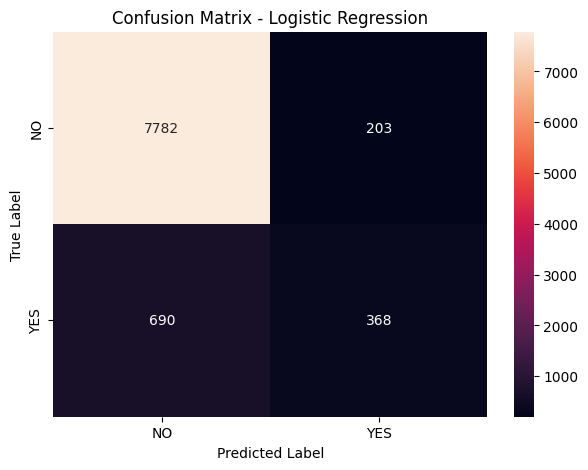

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['NO', 'YES'],
    yticklabels=['NO', 'YES']
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("===== FINAL MODEL METRICS =====")
print(f"Accuracy : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall   : {recall:.4f} ({recall * 100:.2f}%)")
print(f"F1-Score: {f1:.4f} ({f1 * 100:.2f}%)")
print("===============================")

===== FINAL MODEL METRICS =====
Accuracy : 0.9012 (90.12%)
Precision: 0.6445 (64.45%)
Recall   : 0.3478 (34.78%)
F1-Score: 0.4518 (45.18%)


In [16]:
import joblib

model_package = {
    'preprocessor': preprocessor,
    'model': logistic_model
}

model_path = '/content/bank_logistic_regression.pkl'

joblib.dump(model_package, model_path)

print("Model package saved successfully!")
print("Path:", model_path)

Model package saved successfully!
Path: /content/bank_logistic_regression.pkl


In [18]:
readme_content = """
# Bank Marketing Prediction Using Logistic Regression

## Problem Statement

The objective of this project is to develop a Logistic Regression model
to predict whether a bank customer will subscribe to a term deposit.

The target variable is:

- NO: Customer did not subscribe to a term deposit
- YES: Customer subscribed to a term deposit

## Dataset

The Bank Marketing dataset contains 45,211 customer records and 17 attributes.

The dataset contains:

- 45,211 total records
- 16 input features
- 1 target variable (`y`)

The target distribution is:

- NO: 39,922 (88.30%)
- YES: 5,289 (11.70%)

The target variable is imbalanced, with significantly more NO samples
than YES samples.

## Methodology

The following steps were performed:

1. Loaded the Bank Marketing dataset.
2. Inspected the dataset structure and data types.
3. Checked for missing values.
4. Encoded the target variable:
   - NO = 0
   - YES = 1
5. Separated input features and target variable.
6. Split the dataset into 80% training and 20% testing data.
7. Used stratified splitting to preserve the target class distribution.
8. Applied StandardScaler to numerical features.
9. Applied One-Hot Encoding to categorical features.
10. Trained a Logistic Regression model.
11. Generated predictions on the test dataset.
12. Evaluated the model using Accuracy, Precision, Recall, F1-Score,
    Classification Report, and Confusion Matrix.

## Feature Preprocessing

### Numerical Features

The following numerical features were standardized using StandardScaler:

- age
- balance
- day
- duration
- campaign
- pdays
- previous

### Categorical Features

The following categorical features were encoded using One-Hot Encoding:

- job
- marital
- education
- default
- housing
- loan
- contact
- month
- poutcome

After preprocessing, the 16 original features were transformed into
51 numerical features.

## Train-Test Split

The dataset was divided using an 80:20 train-test split.

- Training samples: 36,168
- Testing samples: 9,043

Stratified splitting was used to maintain approximately the same class
distribution in both sets.

## Model

The classification model used in this project is Logistic Regression.

Model configuration:

- Algorithm: Logistic Regression
- Maximum iterations: 1000
- Random state: 42

## Evaluation Metrics

The model was evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

## Results

The model achieved the following results on the test dataset:

| Metric | Score |
|---|---:|
| Accuracy | 90.12% |
| Precision | 64.45% |
| Recall | 34.78% |
| F1-Score | 45.18% |

## Classification Report

| Class | Precision | Recall | F1-Score |
|---|---:|---:|---:|
| NO | 91.86% | 97.46% | 94.57% |
| YES | 64.45% | 34.78% | 45.18% |

## Confusion Matrix

| Actual / Predicted | NO | YES |
|---|---:|---:|
| NO | 7782 | 203 |
| YES | 690 | 366 |

Therefore:

- True Negative (TN): 7,782
- False Positive (FP): 203
- False Negative (FN): 690
- True Positive (TP): 366

## Findings

The Logistic Regression model achieved a high overall accuracy of 90.12%.
However, accuracy alone does not fully represent the model performance
because the dataset is highly imbalanced.

The model achieved a recall of only 34.78% for the YES class. This means
that many customers who actually subscribed to a term deposit were
classified as NO.

The model performed much better on the NO class, achieving a recall of
97.46% and an F1-score of 94.57%.

The difference between the performance of the NO and YES classes indicates
that class imbalance is an important limitation of this model.

## Model Saving

The trained model and preprocessing pipeline were saved together using
Joblib:

`bank_logistic_regression.pkl`

## Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Joblib
- Matplotlib
- Seaborn
- Google Colab

## Conclusion

A Logistic Regression model was successfully developed to predict term
deposit subscription using the Bank Marketing dataset.

The model achieved 90.12% accuracy on the test dataset. However, the
relatively low recall of 34.78% for the YES class shows that the model
has difficulty identifying customers who subscribe to a term deposit.

The class imbalance in the dataset is an important factor affecting the
model's performance. Future work could investigate techniques such as
class weighting, resampling, or alternative classification algorithms
to improve minority-class detection.
"""

with open('/content/README.md', 'w') as f:
    f.write(readme_content)

print("README.md created successfully!")

README.md created successfully!


In [19]:
with open('/content/README.md', 'r') as f:
    content = f.read()

print(content)


# Bank Marketing Prediction Using Logistic Regression

## Problem Statement

The objective of this project is to develop a Logistic Regression model
to predict whether a bank customer will subscribe to a term deposit.

The target variable is:

- NO: Customer did not subscribe to a term deposit
- YES: Customer subscribed to a term deposit

## Dataset

The Bank Marketing dataset contains 45,211 customer records and 17 attributes.

The dataset contains:

- 45,211 total records
- 16 input features
- 1 target variable (`y`)

The target distribution is:

- NO: 39,922 (88.30%)
- YES: 5,289 (11.70%)

The target variable is imbalanced, with significantly more NO samples
than YES samples.

## Methodology

The following steps were performed:

1. Loaded the Bank Marketing dataset.
2. Inspected the dataset structure and data types.
3. Checked for missing values.
4. Encoded the target variable:
   - NO = 0
   - YES = 1
5. Separated input features and target variable.
6. Split the dataset into 80% t

In [20]:
requirements = """pandas
numpy
scikit-learn
joblib
matplotlib
seaborn
"""

with open('/content/requirements.txt', 'w') as f:
    f.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!
